Discount 0.9615
  65 :   175074    141234     78375         0 
  66 :   170875    137755     76188         0 
  67 :   166597    134218     73972         0 
  68 :   162241    130625     71729         0 
  69 :   157812    126980     69461         0 
  70 :   153315    123286     67172         0 
  71 :   148752    119548     64866         0 
  72 :   144130    115769     62544         0 
  73 :   139454    111954     60211         0 
  74 :   134730    108109     57871         0 
  75 :   129966    104240     55528         0 
  76 :   125168    100352     53186         0 
  77 :   120345     96452     50850         0 
  78 :   115505     92547     48525         0 
  79 :   110658     88644     46215         0 
  80 :   105813     84751     43926         0 
  81 :   100980     80875     41663         0 
  82 :    96169     77026     39430         0 
  83 :    91393     73210     37233         0 
  84 :    86661     69438     35078         0 
  85 :    81985     65716     32968         

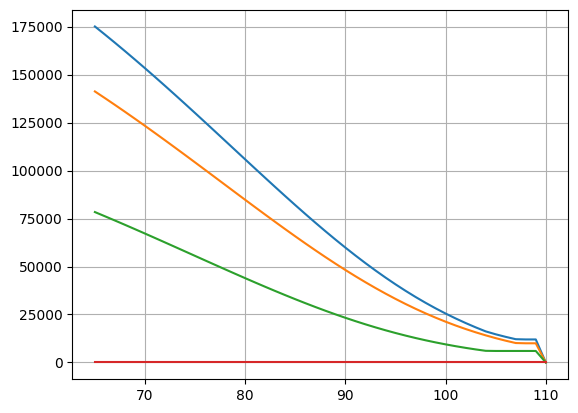

In [3]:
import numpy as np
import matplotlib.pyplot as plt

class Markov:
    def __init__(self):
        self.iNrStates = None
        self.iMaxTime  = None    
        self.dPij = [] # dPij[t][i,j]
        self.dPre = []
        self.dPost= []
        self.dv   = []
        self.dDK  = [] # V[t][i]
        self.dDKDistr  = []
        
        self.bCalculated = False
        self.bCalculatedDistr = False
        self.iStart = None
        self.iStop  = None
        self.fDistrLow = -1000
        self.fDistrHigh = 30000
        self.iNrBuckets = 3300
        self.fBucketWidth = (self.fDistrHigh-self.fDistrLow)/self.iNrBuckets
        self.fBucketWidthRound = self.fBucketWidth / 2.
                
    def vDefineModel(self,iNrStates,iMaxTime=1200):
        self.iNrStates = iNrStates
        self.iMaxTime = iMaxTime
        for i in range(iMaxTime):
            tempPij = np.zeros([iNrStates,iNrStates])
            tempPost = np.zeros([iNrStates,iNrStates])
            tempPre = np.zeros([iNrStates])
            tempDK = np.zeros([iNrStates])
            self.dPij.append(tempPij)
            self.dPost.append(tempPost)
            self.dPre.append(tempPre)
            self.dDK.append(tempDK)
        tempv = np.zeros([iMaxTime])
        self.dv=tempv
        
    def iBucketNr(self, fValue):
        if fValue < self.fDistrLow:
            return(0)
        iBNR = (int(min(self.iNrBuckets-1,(fValue-self.fDistrLow)/self.fBucketWidth+self.fBucketWidthRound)))
        return(iBNR)
    
    def fValueOfBucket(self, iBucket):
        return(self.fBucketWidth*min(self.iNrBuckets-1,iBucket)+self.fDistrLow)
    
    def vCreateDistModel(self):
        print("You Know that you can call me only once everything is done")
        for i in range(self.iMaxTime):
            tempDK = np.zeros([self.iNrStates,self.iNrBuckets])
            self.dDKDistr.append(tempDK)
    
    def vSetDiscount(self,fIRate):
        vTemp = 1./(1.+fIRate)
        print("Discount %.4f"%(vTemp))
        for i in range(self.iMaxTime):
            self.dv[i] = vTemp
        self.bCalculated = False
    
    def vSetPij(self,t,i,j,fValue):
        self.dPij[t][i,j] = fValue
        self.bCalculated = False
    
    def vSetPre(self,t,i,j,fValue):
        self.dPre[t][i] = fValue
        self.bCalculated = False
    
    def vSetPost(self,t,i,j,fValue):
        self.dPost[t][i,j] = fValue
        self.bCalculated = False
    
    
    def doCalculateDK(self,iStart,iStop,iAge,iState):
        self.iStop = iStop
        self.iStart = iStart
        self.bCalculated = True
        for i in range(self.iMaxTime):
            self.dDK[i] *= 0.
        
        for i in range(self.iStart-1, self.iStop-1,-1):
            #print("Calc Time", i)
            for j in range(self.iNrStates):
                self.dDK[i][j] = self.dPre[i][j]
                for k in range(self.iNrStates):
                    self.dDK[i][j] += self.dv[i]*self.dPij[i][j,k]*(self.dPost[i][j,k]+self.dDK[i+1][k])
                    
    def doCalculateDKDistr(self,iStart,iStop,iAge,iState):
        self.iStop = iStop
        self.iStart = iStart
        self.bCalculatedDistr = True
        self.vCreateDistModel()
        for i in range(self.iMaxTime):
            self.dDKDistr[i] *= 0.
        # Set Boundary Conditions
        iIndexSwitch = self.iBucketNr(0)
        for j in range(self.iNrStates):
            value = 0.
            for l in range(self.iNrBuckets):
                if l > iIndexSwitch:
                           value = 1.
                self.dDKDistr[self.iStart][j,l] = value
        # Calculation                   
        for i in range(self.iStart-1, self.iStop-1,-1):
            print("Dirst DK Calc Time", i)
            for j in range(self.iNrStates):
                for k in range(self.iNrStates):
                    for l in range(self.iNrBuckets):
                        dNewXTPlusOne = (self.fValueOfBucket(l) - self.dPre[i][j])/self.dv[i] - self.dPost[i][j,k]
                        self.dDKDistr[i][j,l] += self.dPij[i][j,k]*(self.dDKDistr[i+1][k,self.iBucketNr(dNewXTPlusOne)])
                                      
    
    def dGetDK(self,iStart,iStop,iAge,iState):
        if (iStart != self.iStart or iStop != self.iStop or not(self.bCalculated)):
            self.doCalculateDK(iStart,iStop,iAge,iState)
        return(self.dDK[iAge][iState])
    
    def dGetDKDistr(self,iStart,iStop,iAge,iState,fValue):
        if (iStart != self.iStart or iStop != self.iStop or not(self.bCalculatedDistr)):
            temp = self.dGetDK(iStart,iStop,iAge,iState) # To be on the safe side
            self.doCalculateDKDistr(iStart,iStop,iAge,iState)
        return(self.dDKDistr[iAge][iState,self.iBucketNr(fValue)])
    
    def PrintDKs(self,iStart,iStop):
        for i in range(iStop,iStart+1):
            strTemp = " %3d :"%(i)
            for j in range(self.iNrStates):
                 strTemp += "  %7.0f "%(self.dGetDK(iStart,iStop,i,j))
            print(strTemp)
    
    def PlotDKs(self,iStart,iStop,figNr=1):
        x = []
        y = []
        for i in range(iStop,iStart+1):
            x.append(i)
            ytemp = np.zeros(self.iNrStates)
            for j in range(self.iNrStates):
                ytemp[j] = self.dGetDK(iStart,iStop,i,j)
            y.append(ytemp)
        plt.figure(figNr)
        plt.plot(x,y)
        plt.grid(True)
    
    def PlotDKDistr(self,iStart,iStop, iSteps = None, iStates = [0], iDeltaT = 5, figNr=10, eps = 0.01,legTitle=""):
        if iSteps == None:
            iSteps = []
            for i in range(iStop,iStart,iDeltaT):
                iSteps.append(i)
            iSteps.append(iStart)
        for i in iSteps:
            for j in iStates:
                x = []
                y = []
                for k in range(self.iNrBuckets):
                    xLoc = eps + self.fValueOfBucket(k)
                    yLoc = self.dGetDKDistr(iStart,iStop,i,j,xLoc)
                    x.append(xLoc)
                    y.append(yLoc)
    
                plt.figure(figNr)
                plt.plot(x,y)
                plt.grid(True)
                mylegend = legTitle + "Age %d - State %d"%(i,j)
                plt.title(mylegend)
                figNr+=1
        
def mu(x):
    return(min(1,np.exp(-7.85785 + 0.01538*x + 0.000577355*x**2)))

symMB = Markov()
symMB.vDefineModel(4) # (**), (t*), (*t), (tt)
symMB.vSetDiscount(0.04)

iStart = 110
iStop = 65
AnnuityJoint = 12000 # aPre**
AnnuityWiddow = 10000 # aPret*
AnnuityWiddower = 6000 # aPre*t
iDxy = -3 # y-x - "2nd person 3 yrs younger"

for i in range(iStop,iStart):
    qx = mu(i)
    qy = mu(i+iDxy)
    symMB.vSetPij(i,0,0,(1-qx)*(1-qy))
    symMB.vSetPij(i,0,1, qx*(1-qy))
    symMB.vSetPij(i,0,2,(1-qx)*qy)
    symMB.vSetPij(i,0,3,qx*qy)
    symMB.vSetPij(i,1,1, (1-qy))
    symMB.vSetPij(i,1,3, (qy))
    symMB.vSetPij(i,2,2, (1-qx))
    symMB.vSetPij(i,2,3, (qx))
    symMB.vSetPij(i,3,3, 1.)

    
for i in range(iStop,iStart):
    symMB.vSetPre(i,0,0,AnnuityJoint)
    symMB.vSetPre(i,1,1,AnnuityWiddow)
    symMB.vSetPre(i,2,2,AnnuityWiddower)

symMB.PrintDKs(iStart,iStop)

symMB.PlotDKs(iStart,iStop)


The above example is for an immediate annuity at 65. How does this work for a younger person? Say 35 and in case of death of 1 st person before 65 only widows pension.

Discount 0.9615
  35 :   545745   2148219    212115         0 
  36 :   565867   2132585    220897         0 
  37 :   586760   2116438    230060         0 
  38 :   608457   2099765    239623         0 
  39 :   630993   2082554    249607         0 
  40 :   654406   2064792    260032         0 
  41 :   678737   2046465    270921         0 
  42 :   704027   2027562    282299         0 
  43 :   730322   2008068    294192         0 
  44 :   757673   1987973    306628         0 
  45 :   786134   1967265    319637         0 
  46 :   815761   1945930    333251         0 
  47 :   846619   1923959    347506         0 
  48 :   878778   1901341    362440         0 
  49 :   912313   1878066    378095         0 
  50 :   947308   1854124    394515         0 
  51 :   983857   1829508    411750         0 
  52 :  1022062   1804209    429856         0 
  53 :  1062040   1778221    448890         0 
  54 :  1103918   1751539    468920         0 
  55 :  1147843   1724158    490018         

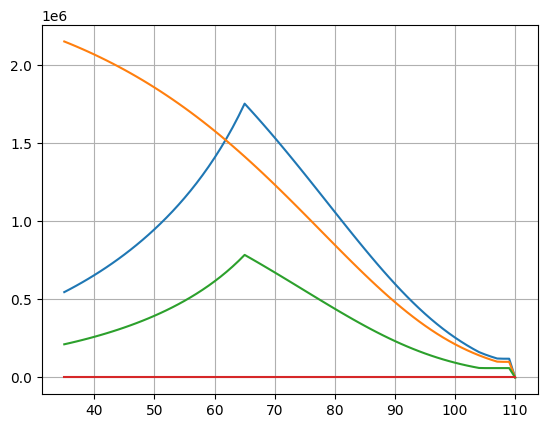

In [4]:
symMB2 = Markov()
symMB2.vDefineModel(4) # (**), (t*), (*t), (tt)
symMB2.vSetDiscount(0.04)

iStart2 = 110
iStop2 = 35
sAge = 65
AnnuityJoint = 120000 # aPre**
AnnuityWiddow = 100000 # aPret*
AnnuityWiddower = 60000 # aPre*t
iDxy = -3 # y-x - "2nd person 3 yrs younger"

for i in range(iStop2,iStart2):
    qx = mu(i)
    qy = mu(i+iDxy)
    symMB2.vSetPij(i,0,0,(1-qx)*(1-qy))
    symMB2.vSetPij(i,0,1, qx*(1-qy))
    symMB2.vSetPij(i,0,2,(1-qx)*qy)
    symMB2.vSetPij(i,0,3,qx*qy)
    symMB2.vSetPij(i,1,1, (1-qy))
    symMB2.vSetPij(i,1,3, (qy))
    symMB2.vSetPij(i,2,2, (1-qx))
    symMB2.vSetPij(i,2,3, (qx))
    symMB2.vSetPij(i,3,3, 1.)

    
for i in range(iStop2,iStart2):
    if i >= 65:
        symMB2.vSetPre(i,0,0,AnnuityJoint)
        symMB2.vSetPre(i,1,1,AnnuityWiddow)
        symMB2.vSetPre(i,2,2,AnnuityWiddower)
    else:
        symMB2.vSetPre(i,0,0,0)
        symMB2.vSetPre(i,1,1,AnnuityWiddow)
        symMB2.vSetPre(i,2,2,0)

symMB2.PrintDKs(iStart2,iStop2)

symMB2.PlotDKs(iStart2,iStop2)

How to finance with premium. P for state ** and nil for widow and widdower

Discount 0.9615
545745.4532298245 17.059087386700735 31991.48001640977 

  35 :       17         0         0         0 
  36 :       17         0         0         0 
  37 :       16         0         0         0 
  38 :       16         0         0         0 
  39 :       16         0         0         0 
  40 :       15         0         0         0 
  41 :       15         0         0         0 
  42 :       15         0         0         0 
  43 :       14         0         0         0 
  44 :       14         0         0         0 
  45 :       13         0         0         0 
  46 :       13         0         0         0 
  47 :       12         0         0         0 
  48 :       12         0         0         0 
  49 :       11         0         0         0 
  50 :       11         0         0         0 
  51 :       10         0         0         0 
  52 :       10         0         0         0 
  53 :        9         0         0         0 
  54 :        9         0         

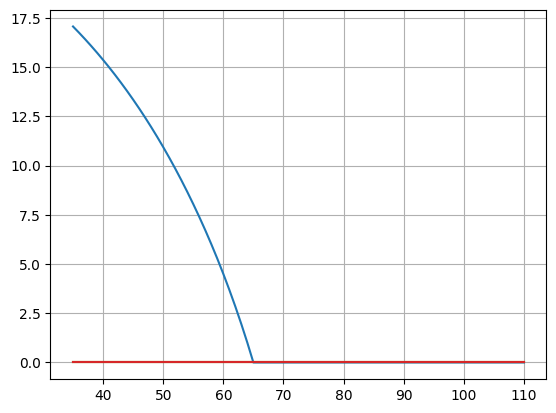

In [5]:
symMP2 = Markov()
symMP2.vDefineModel(4) # (**), (t*), (*t), (tt)
symMP2.vSetDiscount(0.04)

sAge = 65
iDxy = -3 # y-x - "2nd person 3 yrs younger"

for i in range(iStop2,iStart2):
    qx = mu(i)
    qy = mu(i+iDxy)
    symMP2.vSetPij(i,0,0,(1-qx)*(1-qy))
    symMP2.vSetPij(i,0,1, qx*(1-qy))
    symMP2.vSetPij(i,0,2,(1-qx)*qy)
    symMP2.vSetPij(i,0,3,qx*qy)
    symMP2.vSetPij(i,1,1, (1-qy))
    symMP2.vSetPij(i,1,3, (qy))
    symMP2.vSetPij(i,2,2, (1-qx))
    symMP2.vSetPij(i,2,3, (qx))
    symMP2.vSetPij(i,3,3, 1.)

    
for i in range(iStop2,iStart2):
    if i >= 65:
        symMP2.vSetPre(i,0,0,0)
        symMP2.vSetPre(i,1,1,0)
        symMP2.vSetPre(i,2,2,0)
    else:
        symMP2.vSetPre(i,0,0,1)
        symMP2.vSetPre(i,1,1,0)
        symMP2.vSetPre(i,2,2,0)

PVPrem = symMP2.dGetDK(iStart2,iStop2,iStop2,0)
PVBen = symMB2.dGetDK(iStart2,iStop2,iStop2,0)
Premium = PVBen / PVPrem

print(PVBen, PVPrem, Premium, "\n")
        
symMP2.PrintDKs(iStart2,iStop2)

symMP2.PlotDKs(iStart2,iStop2)



Discount 0.9615
  35 :        0   2148219    212115         0 
  36 :    30232   2132585    220897         0 
  37 :    61592   2116438    230060         0 
  38 :    94126   2099765    239623         0 
  39 :   127882   2082554    249607         0 
  40 :   162911   2064792    260032         0 
  41 :   199268   2046465    270921         0 
  42 :   237010   2027562    282299         0 
  43 :   276201   2008068    294192         0 
  44 :   316905   1987973    306628         0 
  45 :   359196   1967265    319637         0 
  46 :   403150   1945930    333251         0 
  47 :   448852   1923959    347506         0 
  48 :   496393   1901341    362440         0 
  49 :   545874   1878066    378095         0 
  50 :   597404   1854124    394515         0 
  51 :   651106   1829508    411750         0 
  52 :   707115   1804209    429856         0 
  53 :   765580   1778221    448890         0 
  54 :   826669   1751539    468920         0 
  55 :   890572   1724158    490018         

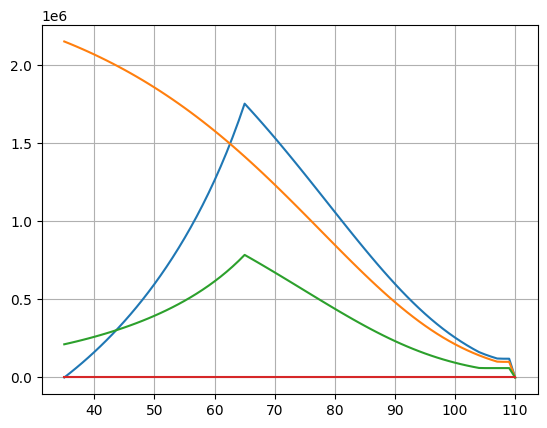

In [6]:
symMT2 = Markov()
symMT2.vDefineModel(4) # (**), (t*), (*t), (tt)
symMT2.vSetDiscount(0.04)

sAge = 65
iDxy = -3 # y-x - "2nd person 3 yrs younger"

for i in range(iStop2,iStart2):
    qx = mu(i)
    qy = mu(i+iDxy)
    symMT2.vSetPij(i,0,0,(1-qx)*(1-qy))
    symMT2.vSetPij(i,0,1, qx*(1-qy))
    symMT2.vSetPij(i,0,2,(1-qx)*qy)
    symMT2.vSetPij(i,0,3,qx*qy)
    symMT2.vSetPij(i,1,1, (1-qy))
    symMT2.vSetPij(i,1,3, (qy))
    symMT2.vSetPij(i,2,2, (1-qx))
    symMT2.vSetPij(i,2,3, (qx))
    symMT2.vSetPij(i,3,3, 1.)

for i in range(iStop2,iStart2):
    if i >= 65:
        symMT2.vSetPre(i,0,0,AnnuityJoint)
        symMT2.vSetPre(i,1,1,AnnuityWiddow)
        symMT2.vSetPre(i,2,2,AnnuityWiddower)
    else:
        symMT2.vSetPre(i,0,0,-Premium)
        symMT2.vSetPre(i,1,1,AnnuityWiddow)
        symMT2.vSetPre(i,2,2,0)

symMT2.PrintDKs(iStart2,iStop2)

symMT2.PlotDKs(iStart2,iStop2) 